# Breast Cancer Diagnosis Prediction using Machine Learning

**Capstone Project ML Notebook**

| Field | Value |
|---|---|
| **Idea Title** | Breast cancer diagnosis prediction using ML |
| **Summary** | Using ML to develop a prediction model for breast cancer diagnosis (benign vs malignant) based on 30 cell nucleus features. *Is tumor size the main predictor?* |
| **Submitted By** | emel.alpay@gmail.com & surabivnaidu@gmail.com |
| **Data Available?** | Yes |
| **Data Source** | [Breast Cancer Wisconsin (Diagnostic) Data Set — UCI Repository](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) |
| **Skills Used** | Python, pandas, visualization, classification, scikit-learn|
| **Course** | BINF.X411.(2) Machine Learning and AI in Bioinformatics, UCSC Silicon Valley Extension |

---

**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC): 569 patients, 30 cell-nucleus features.
- UCI archive: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

### What this notebook covers (progress checkpoint)
1. **Data input**: Load the WDBC dataset into a DataFrame
2. **Data clean-up**: Check for missing values and encode the diagnosis label
3. **Exploratory plots**: Class balance, feature distributions, correlation heatmap, and a PCA view
4. **Train / test data**: Stratified 80/20 split and feature scaling

*Model training, tuning, and evaluation are the next phase of the project.*

### Research Questions
- **RQ1:** Can ML accurately classify breast tumors from 30 cell-nucleus features?
- **RQ2:** Is tumor size really the main predictor, or do other features matter more?

## Installing

This notebook needs `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scikit-learn` (all pre-installed with Anaconda), plus **`ucimlrepo`** to download the dataset directly from UCI.


Run the cell below to download the data.

In [ ]:
pip install ucimlrepo

## Step 1 — Import the libraries we need

We'll use:
- **pandas** to load and explore the data
- **numpy** for number crunching
- **matplotlib** and **seaborn** for plots
- **scikit-learn** for the train/test split, feature scaling, and PCA

In [2]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hide warnings so the output is cleaner
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — for preparing the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Plot style — make plots look nicer
sns.set_style('whitegrid')

# Set a random seed so results are the same every time we run the notebook
SEED = 42
np.random.seed(SEED)

print('All libraries loaded!')

All libraries loaded!


## Step 2 — Load the dataset

We load the data directly from **UCI**, which is the original place where Wolberg, Street, and Mangasarian shared the dataset in 1995. I think this is the most reliable version to use for academic work.

In [3]:
# Load directly from UCI Machine Learning Repository
# This is the canonical, original source — same data the authors deposited in 1995.
# Cite as: Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993).
# Breast Cancer Wisconsin (Diagnostic) [Dataset]. UCI ML Repository.
# DOI: https://doi.org/10.24432/C5DW2B

from ucimlrepo import fetch_ucirepo

# Step 1: download the dataset (id=17 is the WDBC dataset)
print('Downloading data from UCI...')
wdbc = fetch_ucirepo(id=17)
print('Download complete!')

# Step 2: get the features (X) and target (y) as pandas DataFrames
X_data = wdbc.data.features      # the 30 numeric features
y_data = wdbc.data.targets        # the diagnosis column (M or B)

# Step 3: combine them into a single DataFrame called 'df'
# (the rest of the notebook expects one DataFrame with a 'diagnosis' column)
df = X_data.copy()
df['diagnosis'] = y_data['Diagnosis']

# Step 4: rename columns to the standard format used in the rest of the notebook.
# UCI uses suffix numbers: '1' = mean, '2' = standard error, '3' = worst.
# So 'radius1' -> 'radius_mean', 'radius2' -> 'radius_se', 'radius3' -> 'radius_worst'.
suffix_map = {'1': '_mean', '2': '_se', '3': '_worst'}

rename_dict = {}
for col in df.columns:
    if col == 'diagnosis':
        continue
    # Check if column ends in 1, 2, or 3
    last_char = col[-1]
    if last_char in suffix_map:
        base_name = col[:-1]   # everything except the last character
        new_name = base_name + suffix_map[last_char]
        rename_dict[col] = new_name

df = df.rename(columns=rename_dict)

# Quick checks
print('\nDataset loaded!')
print('Shape:', df.shape)
print('First 5 column names:', df.columns.tolist()[:5])
print('Last column:', df.columns.tolist()[-1])
# Sanity check: we should have exactly 30 features + 1 diagnosis column
expected_features = 30
actual_features = df.shape[1] - 1   # minus the diagnosis column
if actual_features != expected_features:
    print(f'⚠️ WARNING: expected {expected_features} features, got {actual_features}')
    print('Columns found:', df.columns.tolist())
else:
    print(f'✓ Got the expected {expected_features} features')

df.head()

Download complete!

Dataset loaded!
Shape: (569, 31)
First 5 column names: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']
Last column: diagnosis
✓ Got the expected 30 features


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## Step 3 — Confirm the data

We should have a DataFrame `df` with **569 rows** and **31 columns** (30 features + 1 `diagnosis` column).

Let's verify it;

In [4]:
# How big is the dataset?
print("Number of patients (rows):", df.shape[0])
print("Number of columns:        ", df.shape[1])
print()

# What columns do we have?
print("Column names:")
print(df.columns.tolist())

Number of patients (rows): 569
Number of columns:         31

Column names:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'diagnosis']


In [5]:
# Are there any missing values? (Hopefully zero!)
missing_count = df.isnull().sum().sum()
print("Total missing values:", missing_count)

Total missing values: 0


In [6]:
# What does the diagnosis column look like?
print("Diagnosis values:")
print(df['diagnosis'].value_counts())
print()
print("As percentages:")
print(df['diagnosis'].value_counts(normalize=True).round(3) * 100, "%")

Diagnosis values:
diagnosis
B    357
M    212
Name: count, dtype: int64

As percentages:
diagnosis
B    62.7
M    37.3
Name: proportion, dtype: float64 %


**What we just learned:**
- ✅ 569 patients, 30 features, no missing values
- ✅ 357 benign (B) and 212 malignant (M)
- ⚠️ The classes are a bit imbalanced (63% benign / 37% malignant), but not too bad

**Note:** `M` means malignant (cancer), `B` means benign (not cancer). The `diagnosis` column is text, we'll need to convert it to numbers for machine learning.

## Step 4 — Convert the diagnosis labels to numbers

Machine learning models work with numbers, so we need to convert the diagnosis labels:

**M = malignant → 1**

**B = benign → 0**

We use malignant = 1 because this is the class we care most about detecting. In cancer diagnosis, missing a malignant case is more serious, so we want the model to have high recall for malignant cases. Recall tells us how many real positive cases the model correctly found.

In [7]:
# Convert M/B to 1/0
df['target'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Quick check
print("After conversion:")
print(df['target'].value_counts())
print()
print("Reminder: 1 = Malignant (cancer), 0 = Benign (no cancer)")

After conversion:
target
0    357
1    212
Name: count, dtype: int64

Reminder: 1 = Malignant (cancer), 0 = Benign (no cancer)


In [8]:
# Now separate the features (X) from the target (y)

# The features are all 30 numeric columns (everything except 'diagnosis' and 'target')
feature_columns = [col for col in df.columns if col not in ['diagnosis', 'target']]

X = df[feature_columns]   # 30 features
y = df['target']          # the answer we want to predict

print("X (features) shape:", X.shape)
print("y (target) shape:  ", y.shape)
print()
print("First 5 feature column names:", feature_columns[:5])

X (features) shape: (569, 30)
y (target) shape:   (569,)

First 5 feature column names: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']


## Step 5 — Explore the data with plots (EDA)

Before training any models, we want to look at the data visually. This is called **EDA** (Exploratory Data Analysis).

We'll make 4 plots:
1. A bar chart of the class balance, showing how many benign vs malignant patients there are.
2. Histograms comparing benign vs malignant for the most interesting features
3. A correlation heatmap to see which features are similar to each other
4. A PCA plot compresses all 30 features into 2D so we can visualize them more easily.

### 5.1 — Bar chart of class balance

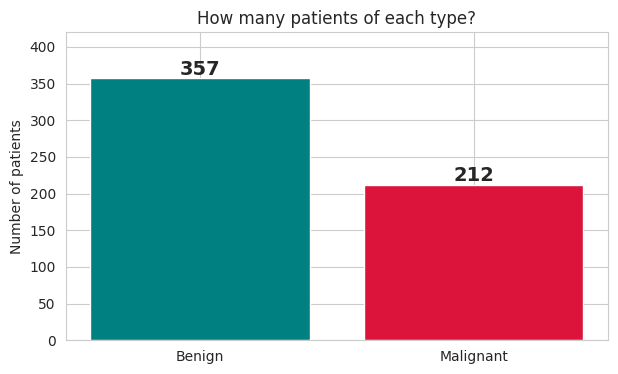

In [9]:
# Make a simple bar chart
plt.figure(figsize=(7, 4))

# Get counts
benign_count = (y == 0).sum()
malignant_count = (y == 1).sum()

# Plot two bars
plt.bar(['Benign', 'Malignant'], [benign_count, malignant_count],
        color=['teal', 'crimson'])

# Add the count numbers on top of each bar
plt.text(0, benign_count + 5, str(benign_count), ha='center', fontsize=14, fontweight='bold')
plt.text(1, malignant_count + 5, str(malignant_count), ha='center', fontsize=14, fontweight='bold')

plt.ylabel('Number of patients')
plt.title('How many patients of each type?')
plt.ylim(0, 420)
plt.show()

### 5.2 — Compare distributions of important features

Let's pick 6 features and see how the *malignant* and *benign* groups differ for each.

Features we will plot:
  - radius_mean
  - texture_mean
  - perimeter_mean
  - area_mean
  - concavity_mean
  - concave_points_mean


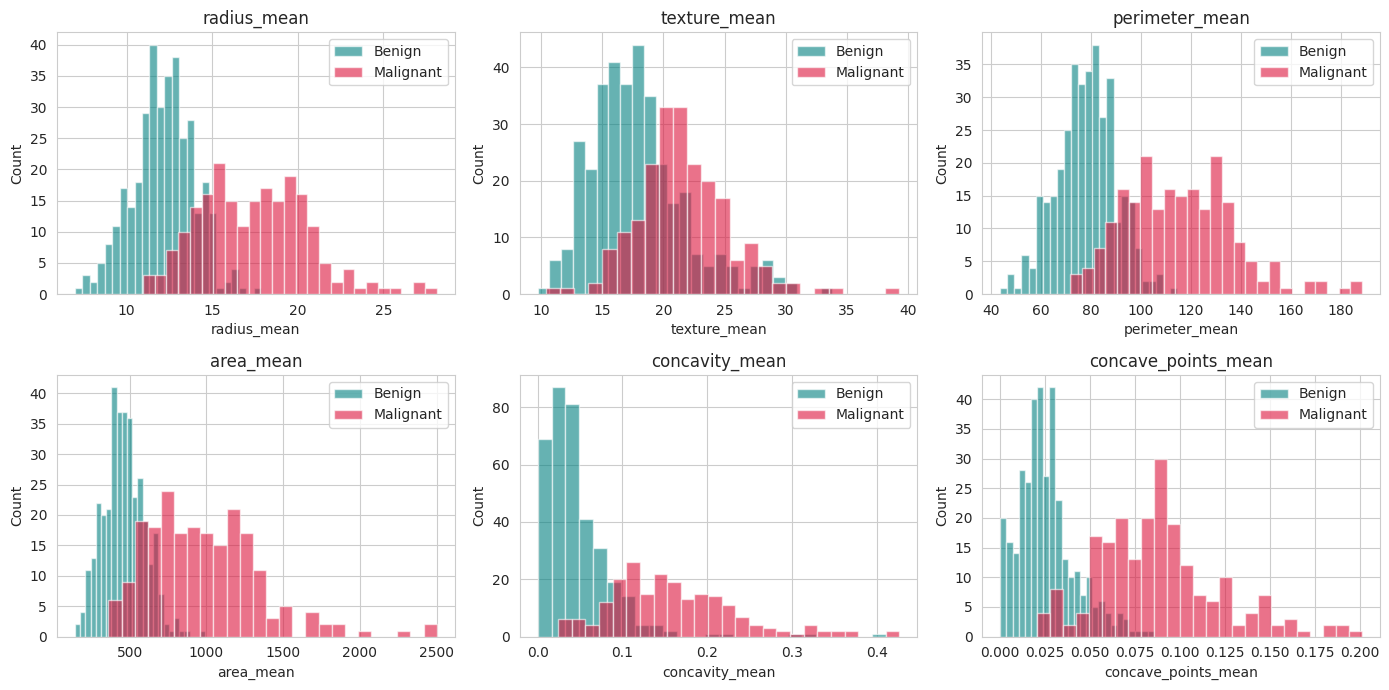

In [10]:
# Pick 6 features to plot — we'll guess these are important based on cell biology
# (tumor size measurements + irregularity measurements)

# Helper function that finds a column whether it's named with a space or underscore
# (different data sources use different conventions for 'concave points')
def find_column(df, name_options):
    '''Try each name in the list and return the first one that exists in df.'''
    for name in name_options:
        if name in df.columns:
            return name
    # If nothing matched, raise a clear error so the student knows what's wrong
    raise KeyError(f'None of these column names found: {name_options}')

# Build the list of features to plot, using the helper to handle naming differences
features_to_check = [
    find_column(df, ['radius_mean']),
    find_column(df, ['texture_mean']),
    find_column(df, ['perimeter_mean']),
    find_column(df, ['area_mean']),
    find_column(df, ['concavity_mean']),
    find_column(df, ['concave_points_mean', 'concave points_mean']),  # space OR underscore
]

print('Features we will plot:')
for f in features_to_check:
    print('  -', f)

# Make a 2x3 grid of histograms
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()   # turn the 2D grid into a 1D list so we can loop

for i in range(len(features_to_check)):
    feature_name = features_to_check[i]
    ax = axes[i]

    # Get the values for benign patients and malignant patients
    benign_values = df[df['target'] == 0][feature_name]
    malignant_values = df[df['target'] == 1][feature_name]

    # Plot both as histograms on the same axes
    ax.hist(benign_values, bins=25, alpha=0.6, label='Benign', color='teal')
    ax.hist(malignant_values, bins=25, alpha=0.6, label='Malignant', color='crimson')

    ax.set_title(feature_name)
    ax.set_xlabel(feature_name)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

**These plots show that:**
- Malignant tumors (red) consistently have **larger** measurements,such as radius, perimeter, and area.
- They also have **more irregular** shapes, with higher concavity and more concave points.
- The benign and malignant groups overlap a little, but they are still fairly different from each other.

This is a good sign because it means the data has clear patterns that the model may be able to learn.

### 5.3 — Correlation heatmap

Some features may be very similar or strongly related to each other. For example, a circle's `radius`, `perimeter`, and `area` are connected because they all describe tumor size.

A correlation heatmap helps us see which featuresareare strongly related and may be measuring almost the same information.

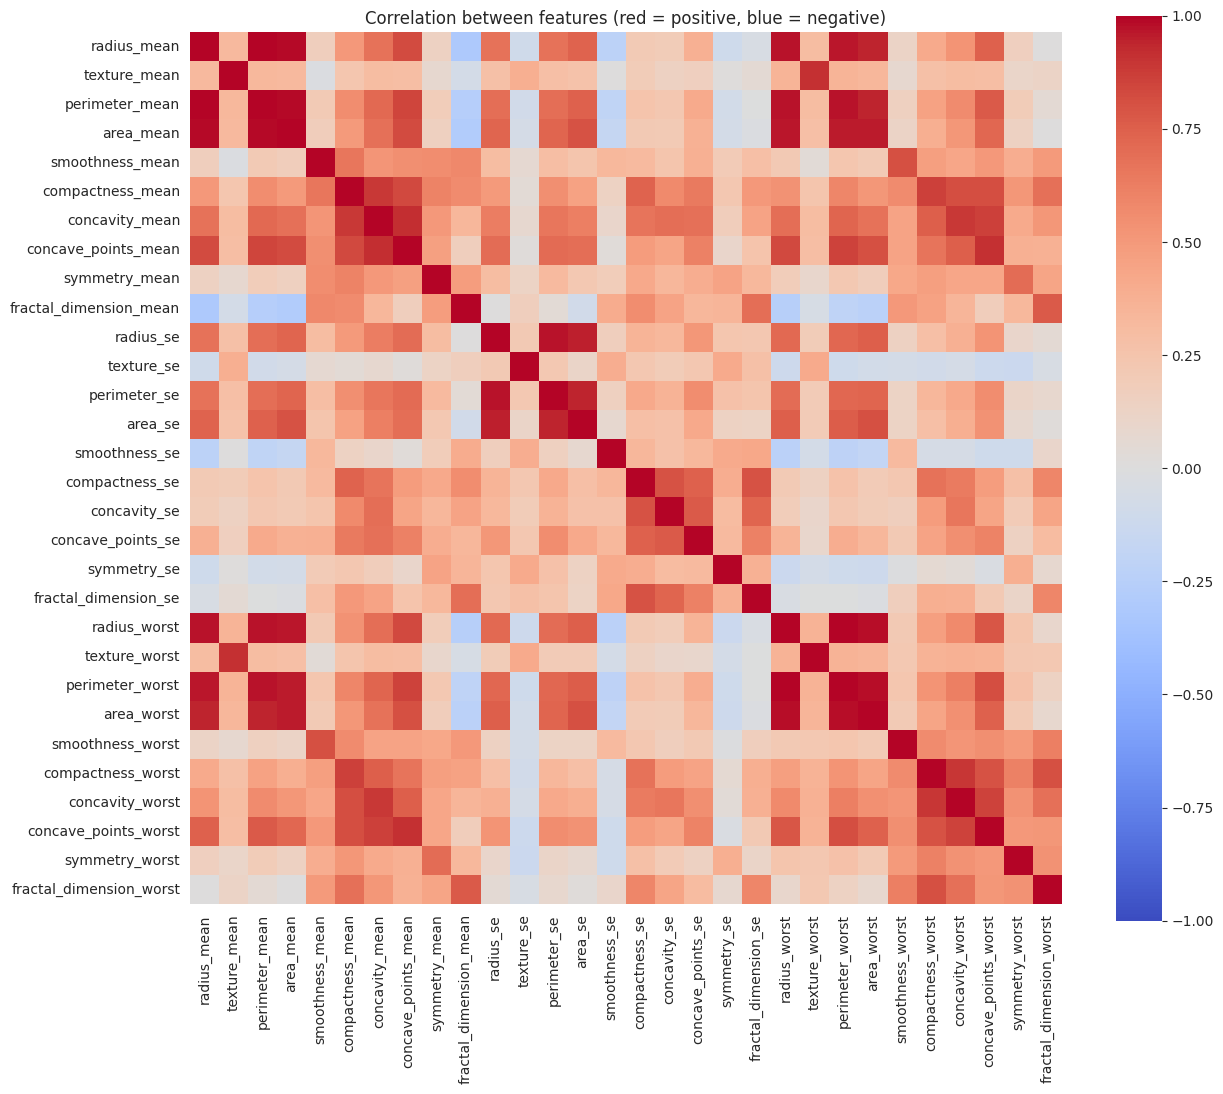

In [11]:
# Compute correlations between all features
correlation_matrix = X.corr()

# Make a big heatmap
plt.figure(figsize=(13, 11))
sns.heatmap(correlation_matrix,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True)
plt.title('Correlation between features (red = positive, blue = negative)')
plt.tight_layout()
plt.show()

In [12]:
# Find and print the most strongly correlated feature PAIRS
# We loop through every pair only once (upper triangle of the matrix)

correlation_pairs = []
columns = correlation_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        feature_a = columns[i]
        feature_b = columns[j]
        corr_value = correlation_matrix.iloc[i, j]
        correlation_pairs.append([feature_a, feature_b, corr_value])

# Convert to a DataFrame so we can sort
pairs_df = pd.DataFrame(correlation_pairs, columns=['Feature_A', 'Feature_B', 'Correlation'])
pairs_df['Abs_Correlation'] = pairs_df['Correlation'].abs()
pairs_df = pairs_df.sort_values('Abs_Correlation', ascending=False)

print("Top 10 most-correlated feature pairs:")
print(pairs_df.head(10).round(3).to_string(index=False))

Top 10 most-correlated feature pairs:
      Feature_A       Feature_B  Correlation  Abs_Correlation
    radius_mean  perimeter_mean        0.998            0.998
   radius_worst perimeter_worst        0.994            0.994
    radius_mean       area_mean        0.987            0.987
 perimeter_mean       area_mean        0.987            0.987
   radius_worst      area_worst        0.984            0.984
perimeter_worst      area_worst        0.978            0.978
      radius_se    perimeter_se        0.973            0.973
 perimeter_mean perimeter_worst        0.970            0.970
    radius_mean    radius_worst        0.970            0.970
 perimeter_mean    radius_worst        0.969            0.969


**Key finding:** Some features have very high correlation, even above 0.99. For example, `radius_mean`, `perimeter_mean`, and `area_mean` are almost measuring the same thing.

This is called **multicollinearity**. It can make some models, like Logistic Regression, less stable. For now, we will keep all the features, but this is something important to remember.

### 5.4 — PCA: Can we see the two classes in 2D?

In machine learning, having too many features can make the data harder to understand. This is called **the curse of dimensionality.** In this dataset, we have 30 features, so it would be helpful to reduce the data into fewer dimensions.

**Dimensionality reduction** helps compress many features into 2 or 3 new features while trying to keep the most important patterns in the data.




There are 3 main dimensionality-reduction tools: PCA, t-SNE, and UMAP

| Method | Type | Strength | Used here? |
|---|---|---|---|
| **PCA** | Linear | Fast, simple, preserves global structure | ✅ Yes (below) |
| **t-SNE** | Nonlinear | Strong at local clusters | ❌ Not needed (PCA works) |
| **UMAP** | Nonlinear | Balances local + global structure, faster than t-SNE | ❌ Not needed (PCA works) |


For this dataset, **PCA** is enough because the benign and malignant groups already separate pretty well in a linear way.

**PCA** works by creating new axes called principal components:

- **PC1** captures the direction where the data varies the most.
- **PC2** captures the next-most important direction, and it is perpendicular to PC1.

If the two classes form distinct groups in the PC1–PC2 plot, that means the data has a strong pattern. This also suggests that even a simple machine learning model may work well.

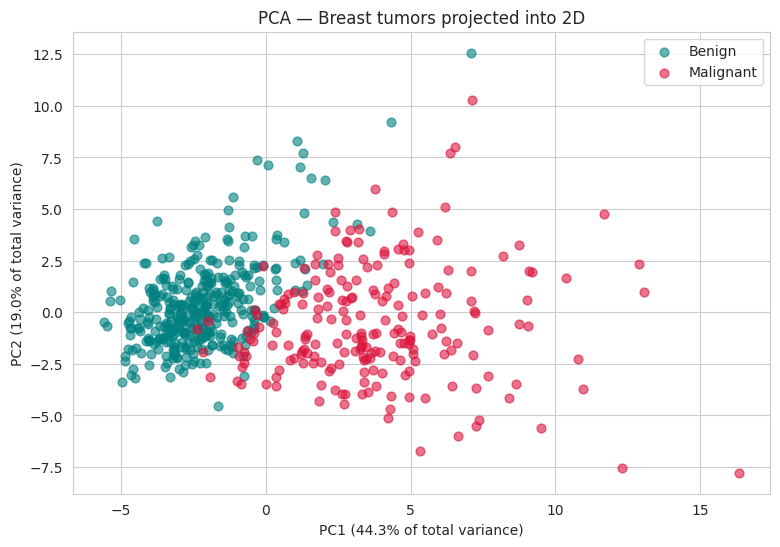


The first 2 components together explain 63.2% of the variance.


In [13]:
# Step 1: Standardize the features (PCA needs this)
scaler_for_pca = StandardScaler()
X_scaled_for_pca = scaler_for_pca.fit_transform(X)

# Step 2: Apply PCA, asking for just 2 components
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled_for_pca)

# Step 3: Plot
plt.figure(figsize=(9, 6))

# Plot benign patients
benign_mask = (y == 0)
plt.scatter(X_pca[benign_mask, 0], X_pca[benign_mask, 1],
            c='teal', label='Benign', alpha=0.6, s=40)

# Plot malignant patients
malignant_mask = (y == 1)
plt.scatter(X_pca[malignant_mask, 0], X_pca[malignant_mask, 1],
            c='crimson', label='Malignant', alpha=0.6, s=40)

# Add labels and title
variance_pc1 = pca.explained_variance_ratio_[0] * 100
variance_pc2 = pca.explained_variance_ratio_[1] * 100
plt.xlabel(f'PC1 ({variance_pc1:.1f}% of total variance)')
plt.ylabel(f'PC2 ({variance_pc2:.1f}% of total variance)')
plt.title('PCA — Breast tumors projected into 2D')
plt.legend()
plt.show()

print(f"\nThe first 2 components together explain {variance_pc1 + variance_pc2:.1f}% of the variance.")

The two classes are almost clearly separated, even when we reduce the data to only **2 dimensions**. This means:
- Simple models, such as Logistic Regression, should perform very well.
- We definitely don't need deep learning here
- The features already contain strong information that can help the model separate benign and malignant tumors.



## Step 6 — Split data into training and test sets

We split the data so we can fairly evaluate the model. If we train and test on the same data, the model may just memorize the answers instead of learning real patterns.
**The split we'll use:**
- 80% for training (about 455 patients)
- 20% for testing (about 114 patients)

We also use **stratify=y** so both sets keep a similar benign/malignant ratio.

Finally, **random_state=SEED** makes the split reproducible, so we get the same result each time we run the notebook.

In [14]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 20% for testing
    random_state=SEED,     # so we get the same split every time
    stratify=y             # keep class balance the same in train and test
)

print("Training set size:", X_train.shape[0], "patients")
print("Test set size:    ", X_test.shape[0], "patients")
print()
print("Training set: Malignant =", (y_train==1).sum(), " Benign =", (y_train==0).sum())
print("Test set:     Malignant =", (y_test==1).sum(), " Benign =", (y_test==0).sum())

Training set size: 455 patients
Test set size:     114 patients

Training set: Malignant = 170  Benign = 285
Test set:     Malignant = 42  Benign = 72


## Step 7 — Scale the features

Many machine learning models, such as **KNN, SVM, Logistic Regression, and neural networks**, work better when all features are on a similar scale.

Right now, our features have very different ranges. For example:

**-radius_mean** ranges from about **7 to 28**

**-area_mean** ranges from about **144 to 2501**

If we don't scale, the model might think `area_mean` is way more important just because it has bigger numbers.

To fix this, we use **StandardScaler**. It changes each feature so that it has:

mean = 0
standard deviation = 1

Important: We fit the scaler only on the training data, then apply it to both the training and test data. This helps prevent data leakage, where information from the test set accidentally influences the training process.

In [15]:
# Create the scaler
scaler = StandardScaler()

# Fit it on training data only, and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the SAME transformation to test data (without re-fitting!)
X_test_scaled = scaler.transform(X_test)

# Let's verify it worked — the mean of each scaled feature should be near 0
print("Average of first 5 features (should be near 0):")
print(X_train_scaled[:, :5].mean(axis=0).round(3))

print("\nStandard deviation of first 5 features (should be near 1):")
print(X_train_scaled[:, :5].std(axis=0).round(3))

Average of first 5 features (should be near 0):
[-0.  0.  0. -0.  0.]

Standard deviation of first 5 features (should be near 1):
[1. 1. 1. 1. 1.]


---

## References

**Dataset**

1. Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993). *Breast Cancer Wisconsin (Diagnostic)* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B

2. Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). Nuclear feature extraction for breast tumor diagnosis. *IS&T/SPIE 1993 International Symposium on Electronic Imaging*, Vol. 1905, pp. 861–870. (The original paper describing how the 30 cell-nucleus features were extracted.)

3. UCI Machine Learning Repository — Breast Cancer Wisconsin (Diagnostic) dataset page. https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic